### Цели и задачи проекта

Цель: провести исследовательский анализ рынка Москвы с уклоном на исследование локации и типа заведения. 

Задачи:
- Загрузить данные и познакомиться с их содержимым.
- Провести предобработку данных.
- Провести исследовательский анализ данных:
 - изучить категории заведений и их количество;
 - исследовать распределение количества заведений по административным районам Москвы;
 - изучить соотношение сетевых и несетевых заведений;
 - исследовать количество посадочных мест в заведениях;
 - исследовать рейтинг заведений;
 - исследовать корреляцию между рейтингом и другими данными;
 - найти топ-15 популярных сетей в Москве и их рейтинг;
 - изучить вариацию среднего чека заведения в зависимости от района;
- Сформулировать выводы по проведённому анализу и рекоммендации заказчику.



### Описание данных

Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
 - 0 — заведение не является сетевым;
 - 1 — заведение является сетевым.
- seats — количество посадочных мест.

Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
- «Средний счёт: 1000–1500 ₽»;
- «Цена чашки капучино: 130–220 ₽»;
- «Цена бокала пива: 400–600 ₽».
и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
 -  Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
 - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
 - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
 - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
 - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
 - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


### Содержимое проекта

Структура проекта:
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.


## 1. Загрузка данных и знакомство с ними

- Загрузим данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
!pip install phik

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

Познакомимся с данными и изучим общую информацию о них:

In [2]:
df1 = pd.read_csv('/datasets/rest_info.csv')
df2 = pd.read_csv('/datasets/rest_price.csv')

In [3]:
df1.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
df2.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

- Датасет rest_info.csv содержит 8406 строк, 9 столбцов. 
- Названия столбцов отражают смысл данных и в одном стиле. 
- В столбцах hours и seats есть пропущенные значения.
- Размерность столбца chain можно оптимизировать (содержит значения 1 и 0)

- Датасет rest_price.csv содержит 4058 строк, 5 столбцов. 
- Названия столбцов отражают смысл данных и в одном стиле. 
- Во всех столбцах кроме id есть пропущенные значения.
- В столбце middle_coffee_cup очень много пропущенных значений

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один. Если сделаем inner join, то потеряем много данных по ресторанам, поэтому делаем left join 

In [7]:
df = df1.merge(df2, on='id', how='left')

In [8]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [9]:
 orig_len = len(df) # храним исходную длину датасета

In [ ]:
temp = df.copy() 
len(temp)

8406

## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:

- Изучим корректность типов данных и при необходимости проведем их преобразование.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [12]:
df['chain'].unique()

array([0, 1])

Проведём оптимизацию целочисленного типа данных:

In [13]:
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [14]:
for column in ['rating','middle_avg_bill','middle_coffee_cup','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных и данных с плавающей запятой.

Узнаем абсолютное и относительное количество пропусков данных:

In [15]:
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [16]:
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Такое большое количество пропусков в price, avg_bill, middle_avg_bill и middle_coffee_cup частично из-за того, что во втором датасете было намного меньше строк, чем в первом, и после merge с left join появились пропуски. Вероятно, для всех этих заведений не были собраны эти данные. Учли данный момент, смотрим дальше.

В столбце middle_coffee_cup самый большой процент пропущенных данных - это не случайно: данный столбец зависит от столбца avg_bill (оценка цены именно на капучино), исследуем количество таких строк:

In [18]:
df['avg_bill'].str.startswith('Цена чашки капучино', na=False).sum()

535

Их всего 535. 

Количество пропусков в часах работы 6 процентов - скорее всего случайность - заполним уникальной заглушкой:

In [20]:
df['hours'].str.contains('unknown').sum()

0

In [21]:
df['hours']= df['hours'].fillna('unknown')

Количество пропусков в количестве посадочных мест, вероятно, не случайна: количество посадочных мест заведений редко указывается в общедоступных. Почти 43% - оставим пропуски.

Средний счет - middle_avg_bill - тоже зависит от столбца avg_bill (средний чек)

In [22]:
df['avg_bill'].unique()

array([nan, 'Средний счёт:1500–1600 ₽', 'Средний счёт:от 1000 ₽',
       'Цена чашки капучино:155–185 ₽', 'Средний счёт:400–600 ₽',
       'Средний счёт:199 ₽', 'Средний счёт:200–300 ₽',
       'Средний счёт:от 500 ₽', 'Средний счёт:1000–1200 ₽',
       'Цена бокала пива:250–350 ₽', 'Средний счёт:330 ₽',
       'Средний счёт:1500 ₽', 'Средний счёт:300–500 ₽',
       'Средний счёт:140–350 ₽', 'Средний счёт:350–500 ₽',
       'Средний счёт:300–1500 ₽', 'Средний счёт:от 240 ₽',
       'Средний счёт:200–250 ₽', 'Средний счёт:328 ₽',
       'Средний счёт:300 ₽', 'Средний счёт:от 345 ₽',
       'Средний счёт:60–400 ₽', 'Средний счёт:900 ₽',
       'Средний счёт:500–800 ₽', 'Средний счёт:500–1000 ₽',
       'Средний счёт:600–700 ₽', 'Цена бокала пива:120–350 ₽',
       'Средний счёт:1000–1500 ₽', 'Средний счёт:1500–2000 ₽',
       'Цена чашки капучино:150–190 ₽', 'Средний счёт:2000–2500 ₽',
       'Средний счёт:600 ₽', 'Средний счёт:450 ₽',
       'Цена чашки капучино:120–170 ₽', 'Средний счё

исследуем количество таких строк:

In [23]:
df['avg_bill'].str.startswith('Средний счёт', na=False).sum()

3149

То есть, часть пропусков естественна - нет среднего счета; также часть могла быть из-за некорректного заполнения.

Оставим как есть, если будем заполнять средним/медианой будут искажения.

В самом avg_bill данные могли быть утеряны или не собраны. Оставим пропуски

Пропуски в ценовой категории (price) не кажутся случайными - при сборе данных могла не определяться категория. Их 18 процентов, оставим, как есть.

In [26]:
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.000000
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Остались пропуски в seats, middle_avg_bill и price, которые мы оставили, чтобы не искажать данные.

Проверим данные на явные и неявные дубликаты. 

Для оптимизации проверки нормализуем данные в текстовых столбцах названия и адреса, удалим дубликаты по адресу и названию, если есть

In [28]:
df.duplicated().sum()

0

In [29]:
df['name']=df['name'].str.lower()

In [30]:
df['name'] = df['name'].str.strip() 

In [31]:
df['address']=df['address'].str.lower()

In [32]:
df['address'] = df['address'].str.strip() 

In [33]:
df.duplicated(subset=['name', 'address']).sum()

4

In [34]:
df = df.drop_duplicates(subset=['name', 'address'])

Проверим уникальность категории и региона

In [35]:
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [36]:
df['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [37]:
df.duplicated().sum()

0

Явных дубликатов нет.

- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [38]:
df['is_24_7'] = (
    df['hours'].str.contains('ежедневно', na=False) &
    df['hours'].str.contains('круглосуточно', na=False)
).astype(int)

df['is_24_7'] = pd.to_numeric(df['is_24_7'], downcast='integer')

In [39]:
# посмотрим на новый столбец
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,0
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,0


---

### Промежуточный вывод


In [41]:
new_len = len(df)

In [42]:
orig_len - new_len

4

In [43]:
perc = round(100* (orig_len - new_len) / orig_len, 2)
perc

0.05

На этом предобработка завершена.

В результате предобработки данных были выполнены следующие действия:
- Два датасета были объединены в один
- Изучены пропуски в данных. Пропуски обнаружились в столбцах `hours` (6%), `seats` (43%), `prices` (60%), `avg_bill` (55%), `middle_avg_bill` (63%) и  `middle_coffee_cup` (94%). Пропуски в `hours` заполонены уникальной заглушкой. Учитывая количество пропусков в других столбцах, они могут отражать особенности данных и не являться ошибкой. Поэтому их оставили как есть.
- Данные проверили на явные и неявные дубликаты. Явных нет. 4 неявных, удалили

В процессе предобработки длина датасета уменьшилась на 4 строки (0.5%)
Был создан новый столбец типа int8

In [45]:
df.info() # датасет после предобработки


<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              8402 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
 13  is_24_7            8402 non-null   int8   
dtypes: float32(4), int8(2), object(8)
memory usage: 738.5+ KB


## 3. Исследовательский анализ данных


---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [46]:
table_cat = (
    df
    .groupby('category')
    .agg({'category': 'count'})
    .rename(columns={'category': 'count'})
    .sort_values(by='count', ascending=False)
    .reset_index()
)

table_cat['share'] = table_cat['count'] / table_cat['count'].sum() * 100
table_cat

,category,count,share
0,кафе,2376,28.278981
1,ресторан,2042,24.303737
2,кофейня,1413,16.817424
3,"бар,паб",764,9.093073
4,пиццерия,633,7.533920
5,быстрое питание,603,7.176863
6,столовая,315,3.749107
7,булочная,256,3.046894


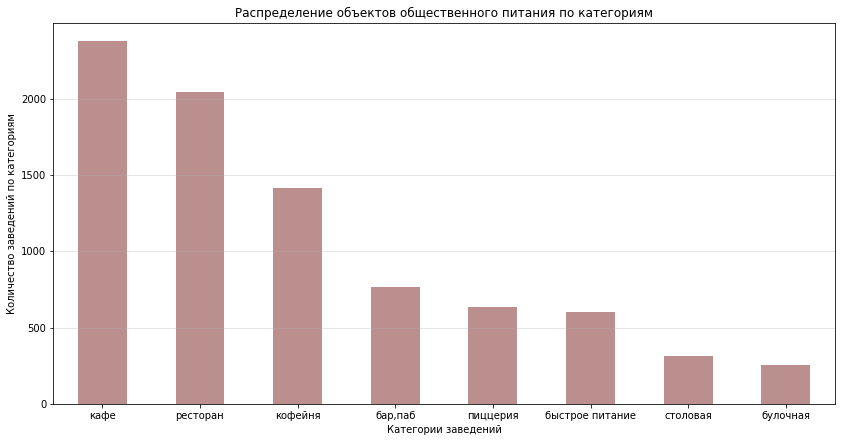

In [47]:
plt.figure(figsize=(14, 7))

df['category'].value_counts().plot(
               kind='bar',
               rot=0,
               legend=False,
               color='rosybrown',
               title=f'Распределение объектов общественного питания по категориям'
)

plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений по категориям')
plt.grid(axis='y', alpha=0.4)
plt.show()

Анализ количества объектов общественного питания разных категорий в Москве может повлиять на решение о выборе типа заведения. Среди всех заведений наиболее распространенные - кафе (28.27% всех заведений), на втором месте - рестораны (24.3%). Такие доли укказывают на жесткую конкуренцию. Наименее распространены булочные (всего 3.04%), что указвает на свободную нишу, или же на малый спрос таких заведений (возможно, предпочитают покупать хлебобулочные изделия в супермаркетах или ходить именно в кафе/кофейни). Возможно, стоит обратить внимание на, напимер, кофейни или бары/пабы, которые пользуются спросом, но не доминируют рынок общепита.

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [48]:
table_dist = (
    df
    .groupby('district')
    .agg({'district': 'count'})
    .rename(columns={'district': 'count'})
    .sort_values(by='count', ascending=False)
    .reset_index()
)

table_dist['share'] = table_dist['count'] * 100 / table_dist['count'].sum() 
table_dist

,district,count,share
0,Центральный административный округ,2242,26.684123
1,Северный административный округ,898,10.687931
2,Южный административный округ,892,10.616520
3,Северо-Восточный административный округ,890,10.592716
4,Западный административный округ,850,10.116639
5,Восточный административный округ,798,9.497739
6,Юго-Восточный административный округ,714,8.497977
7,Юго-Западный административный округ,709,8.438467
8,Северо-Западный административный округ,409,4.867889


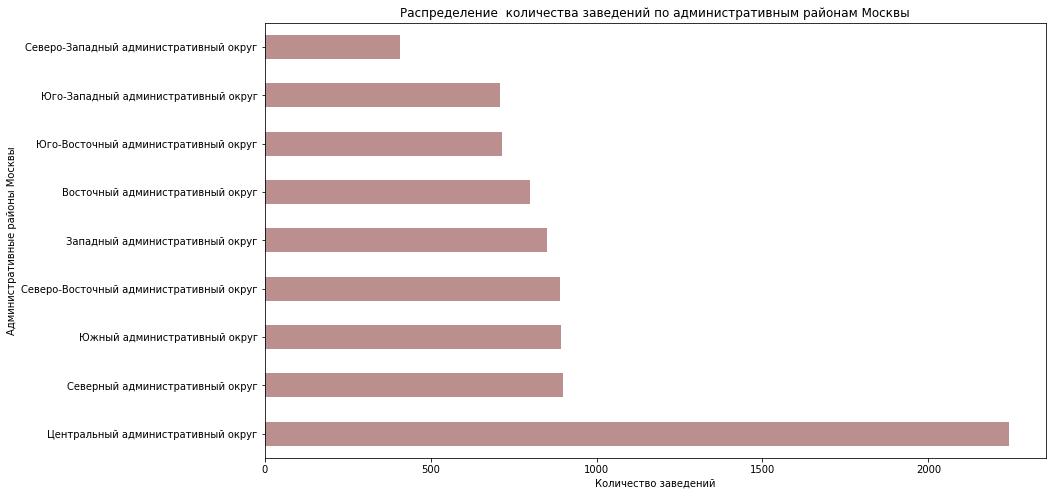

In [49]:
plt.figure(figsize=(14, 8))

df['district'].value_counts().plot(
               kind='barh', 
               rot=0, 
               legend=False,
               color='rosybrown',
               title=f'Распределение  количества заведений по административным районам Москвы'
)

plt.xlabel('Количество заведений')
plt.ylabel('Административные районы Москвы')

plt.show()

Видим, что больше всего заведений в Центральном административном округе Москвы. Посмотрим распределение заведений в этом округе

In [50]:
table_cao = (
    df[df['district'] == 'Центральный административный округ'] 
    .groupby('category')
    .agg({'category': 'count'})
    .rename(columns={'category': 'count'})
    .sort_values(by='count', ascending=False)
    .reset_index()
)

table_cao['share'] = table_cao['count'] * 100 / table_cao['count'].sum()
table_cao

,category,count,share
0,ресторан,670,29.884032
1,кафе,464,20.695807
2,кофейня,428,19.090098
3,"бар,паб",364,16.235504
4,пиццерия,113,5.040143
5,быстрое питание,87,3.880464
6,столовая,66,2.943800
7,булочная,50,2.230152


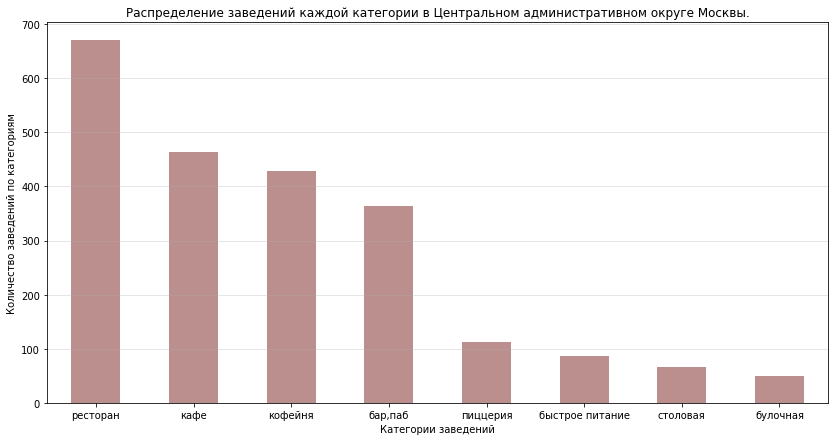

In [51]:
condition = df['district'].str.startswith('Центральный')

plt.figure(figsize=(14, 7))

df['category'][condition].value_counts().plot(
               kind='bar', 
               rot=0, 
               legend=False, 
               color='rosybrown',
               title=f'Распределение заведений каждой категории в Центральном административном округе Москвы.'
)

plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений по категориям')

plt.grid(axis='y', alpha=0.4)
plt.show()

В Центральном округе преобладают рестораны, их почти 30% от всех заведений округа. На втором месте - кафе с чуть более 20% процентов. Малая доля пиццерий, фастфуда, столовых, булочных.
Такой расклад характеризуется сосредоточением достопримечательностей в центре и большим количеством офисов крупных компаний и госучреждений. 
Преобладают учреждения, способные платить за "престижное" местоположение, в то время как булочные и столовые чаще встречаются в спальных районах, где ниже аренда и больше спроса от местных жителей. Если рассматривать открытие заведения в ЦАО, то лучше рассматривать, опять же, кофейни или бары/пабы. Меньше конкуренции но достаточный спрос и средний чек для выживания.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

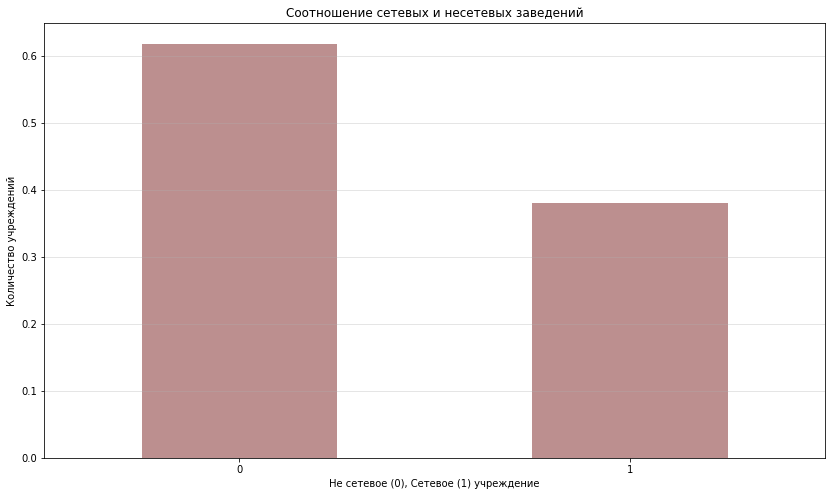

In [52]:
plt.figure(figsize=(14, 8))

df['chain'].value_counts(normalize=True).plot(
               kind='bar', 
               rot=0, 
               legend=False,
               color='rosybrown',
               title=f'Cоотношение сетевых и несетевых заведений'
)

plt.xlabel('Не сетевое (0), Сетевое (1) учреждение')
plt.ylabel('Количество учреждений')
plt.grid(axis='y', alpha=0.4)
plt.show()

Не сетевые заведения составляют более 60% от всех заведений.

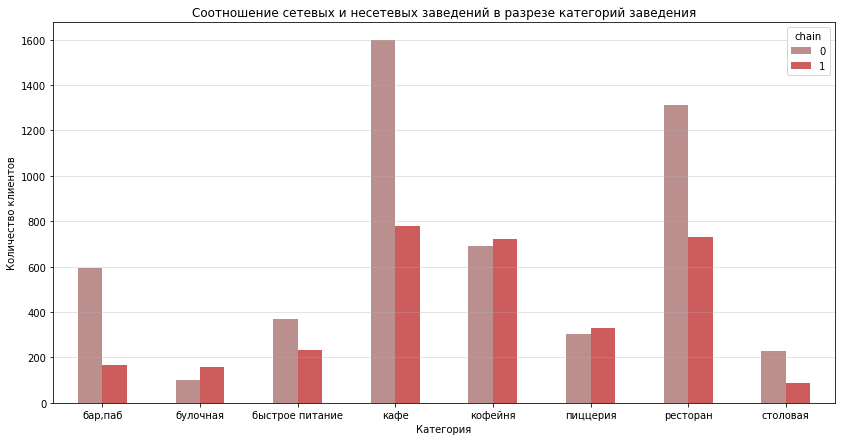

In [53]:
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Cоотношение сетевых и несетевых заведений в разрезе категорий заведения',
               legend=True,
               ylabel='Количество клиентов',
               xlabel='Категория',
               rot=0,
               color = ['rosybrown','indianred'],
               figsize=(14, 7))

plt.grid(axis='y', alpha=0.4)
plt.show()

Рассматривая, являются ли заведения Москвы сетевыми или не сетевыми, получаем результат: более 60% НЕ сетевых. И правда, открыть одно заведение легче, чем целую сеть. Но если рассматривать по виду заведений, кофейни, пиццерии и булочные все же чаще являются сетевыми - легче масштабировать бизнес на целую сеть.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [54]:
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Есть правосторонняя асимметрия данных (среднее больше медианы). Большой разброс данных. Высокое максимальное значение. Есть аномальные значения/выбросы справа. Подтвердим следующими графиками:

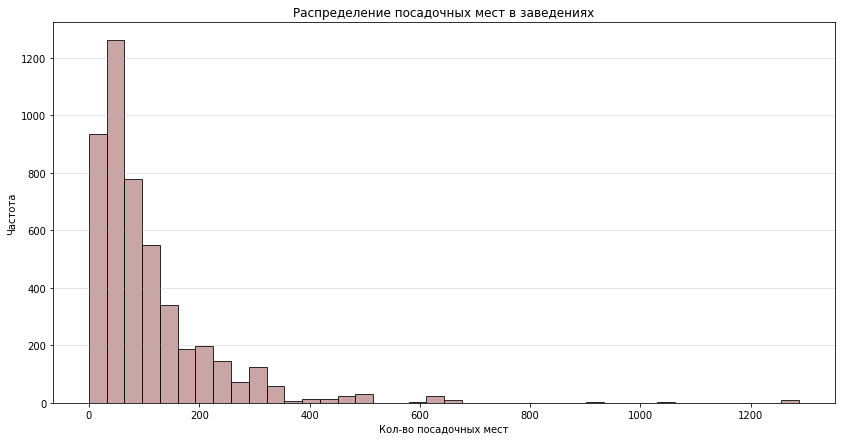

In [55]:
plt.figure(figsize=(14, 7))


df['seats'].plot(
                kind='hist', 
                bins=40, 
                alpha=0.8,
                color='rosybrown',
                edgecolor='black',
                rot=0,
)
plt.title('Распределение посадочных мест в заведениях')
plt.xlabel('Кол-во посадочных мест')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.4)
plt.show()

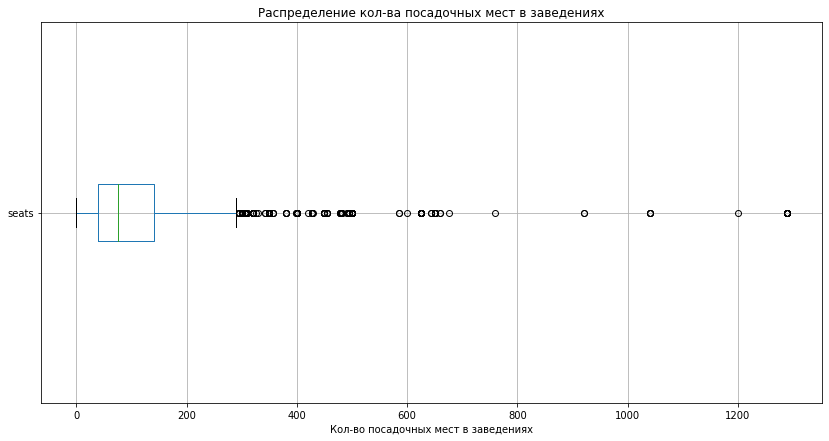

In [56]:
plt.figure(figsize=(14, 7))

df.boxplot(column='seats', vert=False)

plt.title('Распределение кол-ва посадочных мест в заведениях')
plt.xlabel('Кол-во посадочных мест в заведениях')

plt.show()

Такие высокие значения могут быть только в случае заведения-банкетного зала (крупного ресторана), или была допущена ошибка при заполнении данных (например, лишняя цифра)

In [57]:
table_seats = (
    df
    .groupby('category')
    .agg({'seats': 'median'}) 
    .rename(columns={'seats': 'median_seats'}) 
    .sort_values(by='median_seats', ascending=False)
    .reset_index()
)

table_seats

,category,median_seats
0,ресторан,86.0
1,"бар,паб",82.0
2,кофейня,80.0
3,столовая,75.5
4,быстрое питание,65.0
5,кафе,60.0
6,пиццерия,55.0
7,булочная,50.0


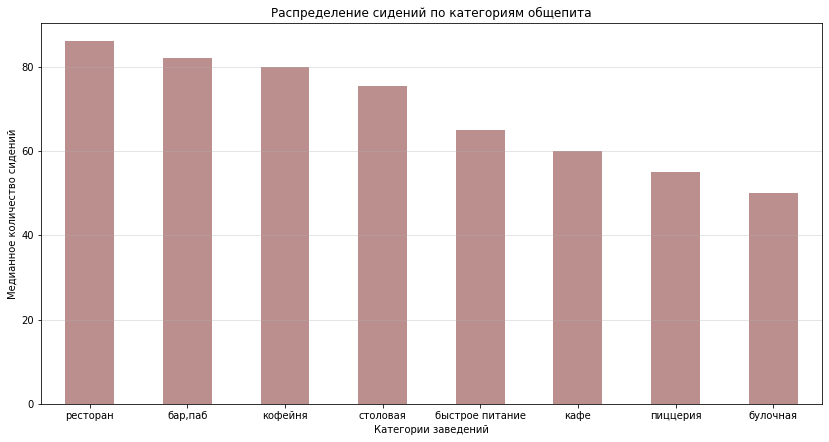

In [58]:
plt.figure(figsize=(14, 7))

df.groupby('category')['seats'].median().sort_values(ascending=False).plot(
               kind='bar',
               rot=0,
               legend=False,
               color='rosybrown',
               title=f'Распределение сидений по категориям общепита'
)

plt.xlabel('Категории заведений')
plt.ylabel('Медианное количество сидений')
plt.grid(axis='y', alpha=0.4)
plt.show()

При открытии заведения общественного питания важно оценивать вместимость помещения и количество мест.

Если рассматривать заведения в общем, типичное число сидений (медиана) - 75.
В данных есть много выбросов справа, среднее значение смещено из-за крупных заведений (типа фуд-кортов или банкетных залов). 

Если рассмотреть посадочные места по категориям заведений, то в топе - рестораны (медиана 86). Часто имеют несколько залов, готовят на компании людей. Бары на втором месте (82) - высокая плотность посадки. Меньше всего мест в пекарнях (50). 50 кажется большим числом для пекарни, ведь традиционно это магазин с выпечкой, но сейчас также существуют пекарни-кондитерские, где сидят с ноутбуками, и даже крупные сети, поэтому такое значение оправдывается. 

Анализ количества мест по типу может помочь при выборе заведения для открытия.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [59]:
df['rating'].describe(percentiles=[0.1, 0.15, 0.25, 0.5, 0.75])

count    8402.000000
mean        4.230016
std         0.470320
min         1.000000
10%         3.800000
15%         4.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

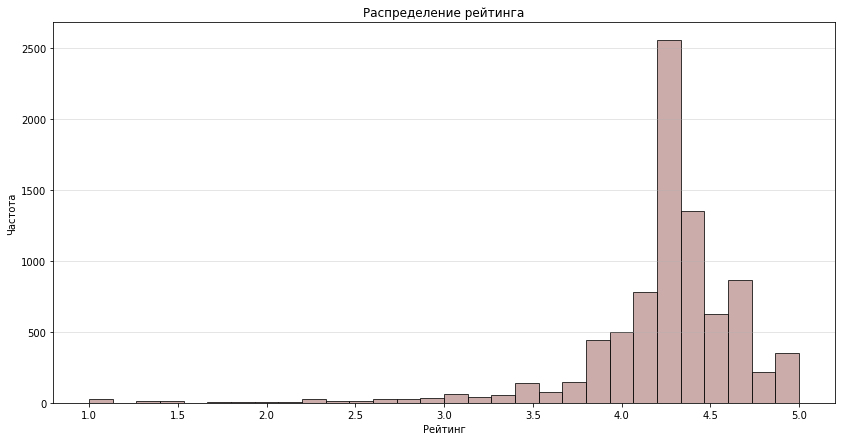

In [60]:
# посморим сначала на распределение рейтинга в общем
plt.figure(figsize=(14,7))

df['rating'].plot(
                kind='hist', 
                bins=30, 
                alpha=0.75,
                color='rosybrown',
                edgecolor='black',
                rot=0, 
)

plt.title('Распределение рейтинга')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

plt.grid(axis='y', alpha=0.4)
plt.show()

Распределение с отрицательной асимметрией

In [61]:
df.groupby('category')['rating'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


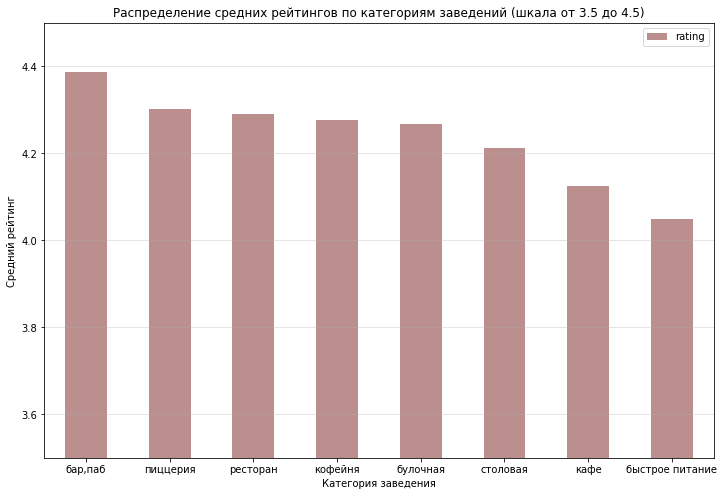

In [62]:
#  теперь посмотрим на средний рейтинг по категориям
grouped = df.groupby('category')['rating'].mean().sort_values(ascending=False)
grouped.plot(kind='bar',
               title=f'Распределение средних рейтингов по категориям заведений (шкала от 3.5 до 4.5)',
               legend=True,
               ylabel='Средний рейтинг',
               xlabel='Категория заведения',
               color='rosybrown',
               rot=0,
               figsize=(12, 8))

plt.grid(axis='y', alpha=0.4)
plt.ylim(3.5, 4.5)
plt.show()

Среднее по рейтингу заведений в Москве - 4.23. Всего лишь менее 15% заведений с рейтингом, ниже 4.0.

Усреднённые рейтинги для разных типов общепита колеблются от 4 (быстрое питание, люди заходят, чаще всего, для перекуса и быстрого обсуживания, могут остаться недовольны обслуживанием или качеством) до 4.4 (бар/паб - меньше возможностей не быть удовлетворенным едой, посещают постоянные клиенты, которым нравится атмосфера). Разная целевая аудитория и ожидания приводят к разным рейтингам.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [63]:
correlation_matrix = df[[
    'rating',
    'category',
    'district',
    'chain',
    'seats',
    'price',
    'is_24_7']].phik_matrix()

print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating', ['rating']].sort_values(by='rating', ascending=False)


interval columns not set, guessing: ['rating', 'chain', 'seats', 'is_24_7']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


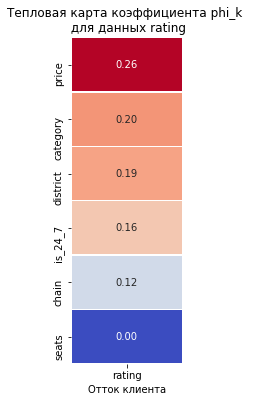

In [64]:
plt.figure(figsize=(2, 6))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5, 
            cbar=False 
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Отток клиента')

plt.show()

Самая сильная связь рейтинга - с ценовой категорией.

In [65]:
table_price = (
    df
    .groupby('price')
    .agg({'rating': 'mean'}) 
    .rename(columns={'rating': 'mean_rating'}) 
    .sort_values(by='mean_rating', ascending=False)
    .reset_index()
)

table_price

,price,mean_rating
0,высокие,4.436611
1,выше среднего,4.386348
2,средние,4.297874
3,низкие,4.173077


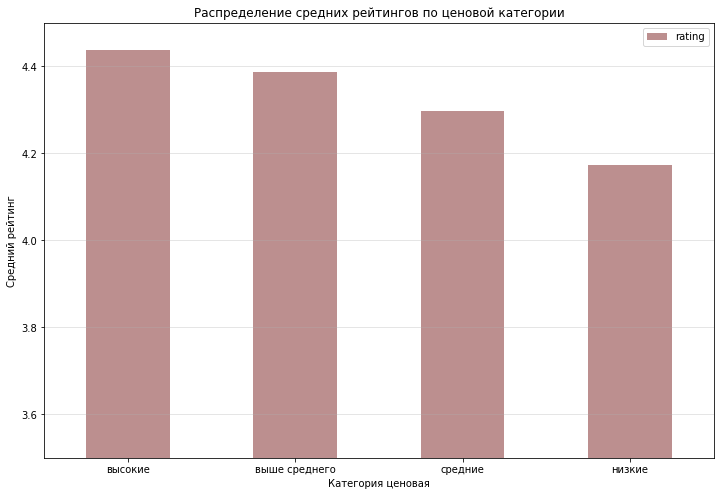

In [66]:
grouped_rating = df.groupby('price')['rating'].mean().sort_values(ascending=False)
grouped_rating.plot(kind='bar',
               title=f'Распределение средних рейтингов по ценовой категории',
               legend=True,
               ylabel='Средний рейтинг',
               xlabel='Категория ценовая',
               color='rosybrown',
               rot=0,
               figsize=(12, 8))

plt.grid(axis='y', alpha=0.4)
plt.ylim(3.5, 4.5)
plt.show()

Рейтинги заведений показывают самую сильную связь с ценовой категорией. Связь ценовой категории и рейтинга такова: у заведений с более высокой ценовой категорией и рейтинг больше. Вероятно, сказывается качество ингредиентов и обслуживания. 

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [67]:
# топ-15 популярных сетей, количество их заведений и категория
top_15_names = df[df['chain'] == 1]['name'].value_counts().head(15).index

top_15_table = (
    df[(df['name'].isin(top_15_names))]
    .groupby('name')
    .agg({'name': 'count', 'category': 'first', 'rating' :'mean'}) 
    .rename(columns={'name': 'count'})           
    .sort_values(by='count', ascending=False)    
    .reset_index()                               
)

print(top_15_table.to_string(index=False))


                               name  count        category   rating
                        шоколадница    120         кофейня 4.177500
                     домино'с пицца     77        пиццерия 4.171429
                         додо пицца     74        пиццерия 4.286487
                   one price coffee     72         кофейня 4.069445
                       яндекс лавка     69        ресторан 3.872464
                              cofix     65         кофейня 4.075385
                              prime     50        ресторан 4.116000
                         хинкальная     44 быстрое питание 4.322727
                           кофепорт     42         кофейня 4.147619
кулинарная лавка братьев караваевых     39            кафе 4.394872
                            теремок     38        ресторан 4.123684
                            чайхана     37            кафе 3.924324
                           cofefest     32         кофейня 3.984375
                            буханка     32      

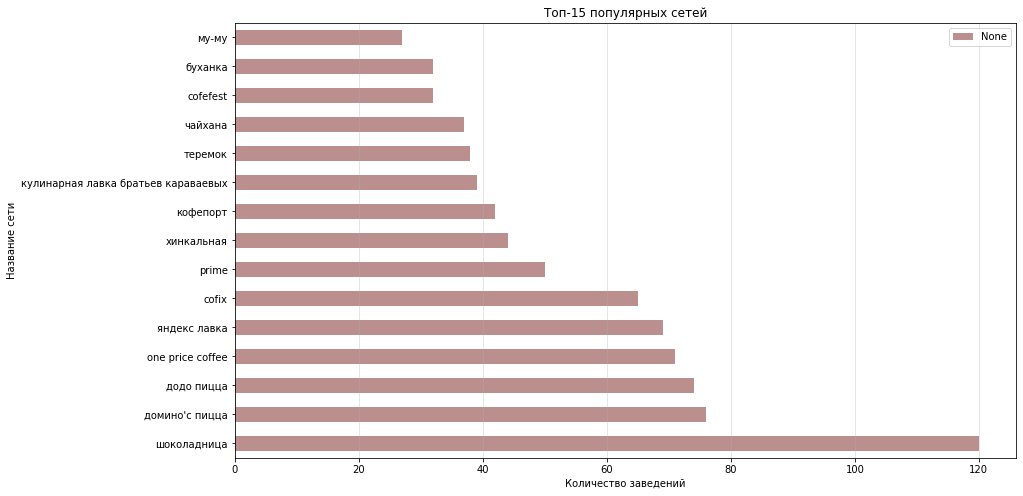

In [68]:
group_popular = df[df['chain'] == 1].groupby('name').size().sort_values(ascending=False).head(15)
pop_plot = group_popular.plot(kind='barh',
               title=f'Топ-15 популярных сетей',
               legend=True,
               color='rosybrown',
               rot=0,
               figsize=(14, 8),
                  sharex=False)
pop_plot.set_ylabel('Название сети')
pop_plot.set_xlabel('Количество заведений')
plt.grid(axis='x', alpha=0.4)
plt.show()

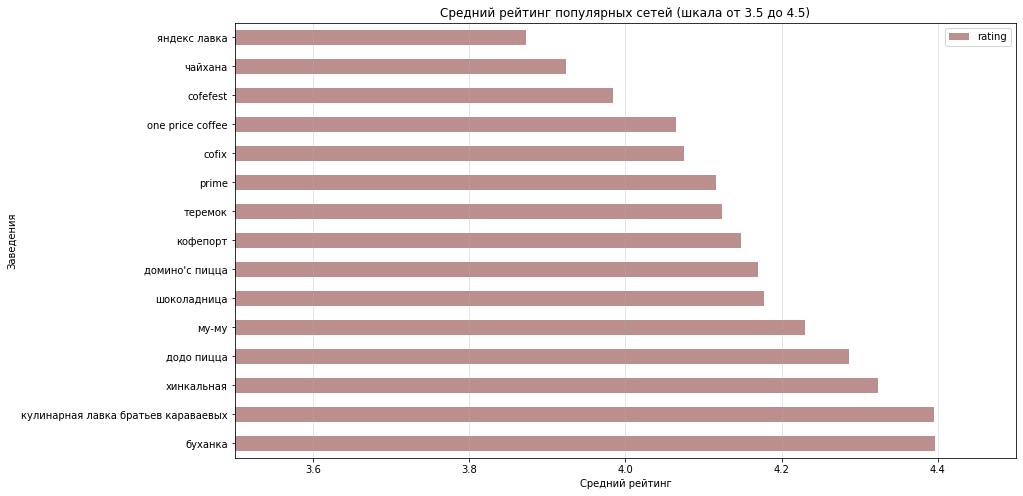

In [69]:
pop_names = group_popular.index
df_names = df[df['chain'] == 1].loc[df['name'].isin(pop_names)]

group_pop = df_names.groupby('name')['rating'].mean().sort_values(ascending=False)
gr_plot = group_pop.plot(kind='barh',
               title=f'Средний рейтинг популярных сетей (шкала от 3.5 до 4.5)',
               legend=True,
               color='rosybrown',
               rot=0,
               figsize=(14, 8))

gr_plot.set_ylabel('Заведения')
gr_plot.set_xlabel('Средний рейтинг')
plt.grid(axis='x', alpha=0.4)
plt.xlim(3.5, 4.5)
plt.show()

Был найден топ-15 популярных сетей по их количеству, их рейтинг и тип заведения. В топе - кофейня "Шоколадница" с рейтингом 4.1775. На втором месте - пиццерия "Домино'с пицца". Замыкает топ-15 кафе "Му-Му". Интересно, что первые 4 популярные сети являются кофейнями и пиццериями. В топе сетей преимущественно кофейни, также есть рестораны, кафе и пиццерии, есть всего одна сетевая булочная, "Буханка", у которой самый высокий рейтинг из рассматриваемого топа.
Топ популярных сетей хорошо отражает рынок сетевых заведений общепита.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


Изучим средний чек заведений

In [70]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.732849
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

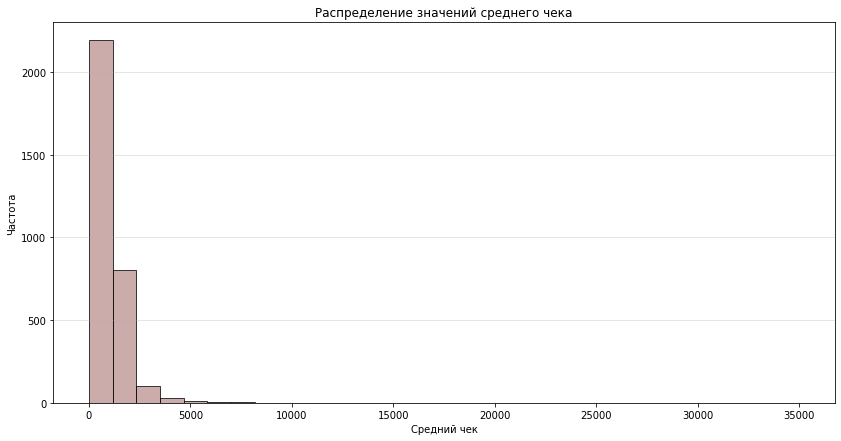

In [71]:
plt.figure(figsize=(14,7))

df['middle_avg_bill'].plot(
                kind='hist', 
                bins=30, 
                alpha=0.75,
                color='rosybrown',
                edgecolor='black',
                rot=0, 
)

plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

plt.grid(axis='y', alpha=0.4)
plt.show()

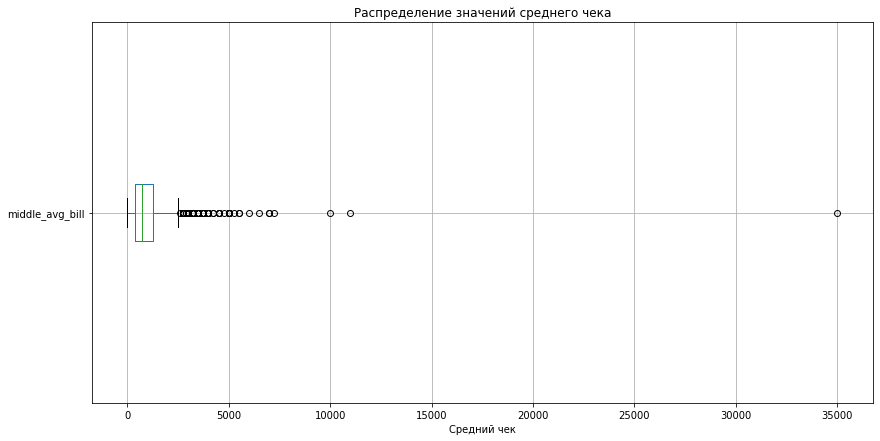

In [72]:
plt.figure(figsize=(14, 7))

df.boxplot(column='middle_avg_bill', vert=False)

plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')

plt.show()

Медиана - 750р,  среднее 958р завышено выбросами справа, экстремально большое максимальное значение среднего чека 35000р (эксклюзивный делюкс-ресторан? Ошибка заполнения?)

In [73]:
table_check = (
    df
    .groupby('district')['middle_avg_bill']
    .agg(['median', 'mean']) 
    .sort_values(by='mean', ascending=False)
    .reset_index()
)

table_check.columns = ['district', 'median_bill', 'mean_bill']
table_check

,district,median_bill,mean_bill
0,Центральный административный округ,1000.0,1191.057495
1,Западный административный округ,1000.0,1053.225464
2,Северный административный округ,650.0,927.959656
3,Южный административный округ,500.0,834.398071
4,Северо-Западный административный округ,700.0,822.222900
5,Восточный административный округ,575.0,820.626953
6,Юго-Западный административный округ,600.0,792.561707
7,Северо-Восточный административный округ,500.0,716.611267
8,Юго-Восточный административный округ,450.0,654.097961


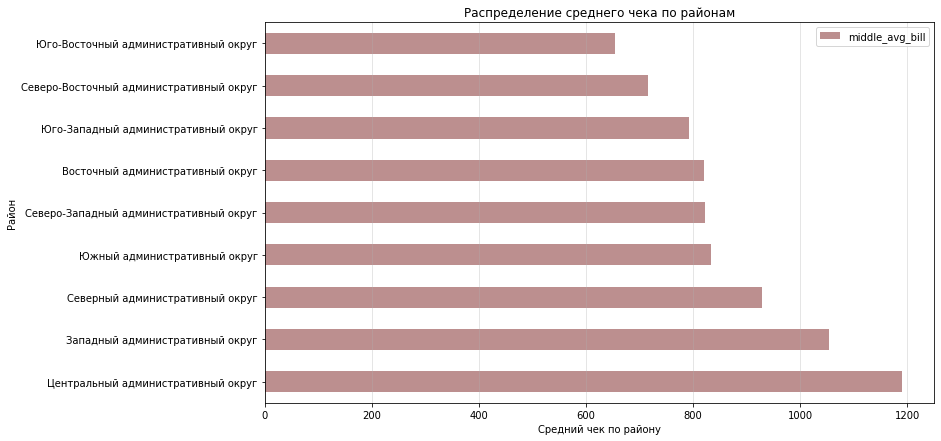

In [74]:
grouped = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)

m_plot = grouped.plot(kind='barh',
                 title='Распределение среднего чека по районам',
                 legend=True,
                 color='rosybrown',
                 figsize=(12, 7))

m_plot.set_xlabel('Средний чек по району')
m_plot.set_ylabel('Район')

plt.grid(axis='x', alpha=0.4)
plt.show()


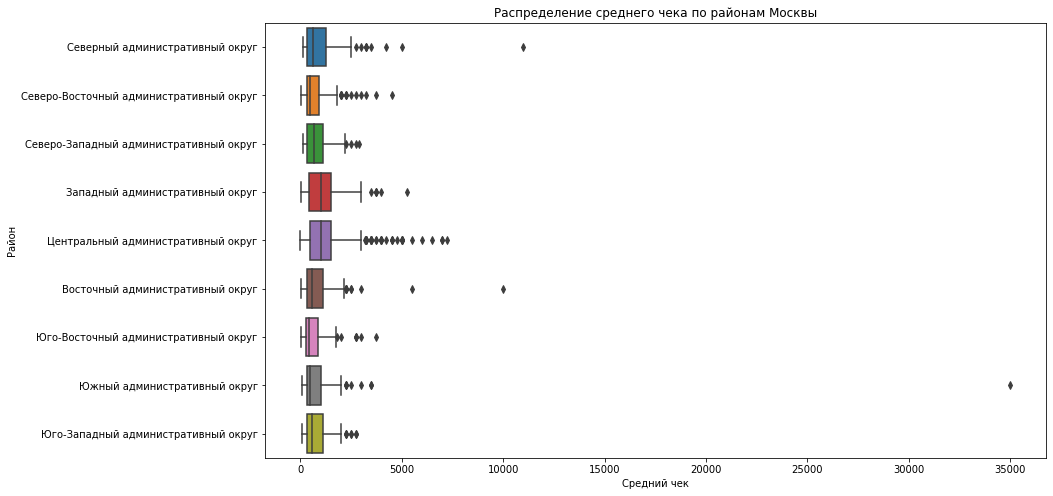

In [75]:
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df, x='middle_avg_bill', y='district', ax=ax).set(
    title='Распределение среднего чека по районам Москвы',
    xlabel='Средний чек',
    ylabel='Район'
)
plt.xticks(rotation=0)
plt.show()

Цены в заведениях больше всего в центре Москвы.

В Центральном округе самый большой средний чек, что обусловленно близостью к центру, концентрацией дорогих ресторанов и высокой заработной платой. В Юго-Восточном округе самый низкий средний чек, что обусловлено спецификой жилого района; низкий чек интерпретируется как ориентация рынка на ежедневные бизнес-ланчи, быстрые перекусы вне дома и высокую чувствительность потребителей к цене в этих локациях. Юго-Западный округ характеризуется «ровным» составом заведений, преобладают рестораны среднего ценового сегмента без резких перекосов в сторону люкса или дешевого фастфуда, откуда всего лишь минимальные выбросы.

---

### Промежуточный вывод


Раздел исследовательского анализа данных завершен. Получили следующие результаты:

1. Исследовали популярность различных типов объектов общественного питания в Москве. Сильная конкуренция заведений типа кафе и ресторан. Наименее распространены булочные.
2. Рассмотрели Центральный округ: преобладают рестораны, на втором месте - кафе. Малая доля пиццерий, фастфуда, столовых, булочных.
3. Рассматривая, являются ли заведения Москвы сетевыми или не сетевыми, получаем результат: более 60% НЕ сетевых. Но если рассматривать по виду заведений, кофейни, пиццерии и булочные все же чаще являются сетевыми.
4. Типичное число сидений в заведении - 75. В используемых данных по сидениям есть много экстремально больших значений из-за крупных заведений. Если рассмотреть посадочные места по категориям заведений, то в топе - рестораны, бары на втором месте, меньше всего мест в пекарнях.
5. Среднее по рейтингу заведений в Москве - 4.23. Всего лишь менее 15% заведений с рейтингом, ниже 4.0. Усреднённые рейтинги для разных типов общепита колеблются от 4 до 4.4. Разная целевая аудитория и ожидания приводят к разным рейтингам.
6. Рейтинги заведений показывают самую сильную связь с ценовой категорией. Связь цены и рейтинга такова: у заведений с более высокой ценовой категорией и рейтинг больше.
7. Был найден топ-15 популярных сетей по их количеству, их рейтинг и тип заведения. Первые 4 популярные сети являются кофейнями и пиццериями. В топе сетей преимущественно кофейни, также есть рестораны, кафе и пиццерии, есть всего одна сетевая булочная, у которой самый высокий рейтинг из рассматриваемого топа.
8. Локация влияет на средний чек: В Центральном округе самый большой средний чек, в Юго-Восточном - самый низкий. Юго-Западный округ - минимальные выбросы.


## 4. Итоговый вывод и рекомендации


В ходе исследования проанализировали данные о заведениях общественного питания Москвы. Данные содержали информацию о заведениях общественного питания и о средних чеках заведений. Акцент исследования был на локациях, типах заведений и их рейтинге, также изучались посадочные местах и средний чек заведений.

Целью проекта было проведение исследовательского анализ рынка Москвы с уклоном на исследование локации и типа заведения. Были поставлены следующие задачи:

- Загрузка данных и знакомство с их содержимым.
- Предобработка данных.
- Исследовательский анализ данных
 - изучение категории заведений и их количество;
 - исследование распределения количества заведений по административным районам Москвы;
 - изучение соотношение сетевых и несетевых заведений;
 - исследование количества посадочных мест в заведениях;
 - исследование рейтинга заведений;
 - исследование корреляции между рейтингом и другими данными;
 - нахождение топ-15 популярных сетей в Москве и их рейтинг;
 - изучение вариации среднего чека заведения в зависимости от района;
А также формулировка выводов по проведённому анализу и предложение рекоммендаций заказчику.

Были выполнены следующие шаги:

1. Загрузка данных и знакомство с ними, объединение двух датасетов
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы и рекоммендации

**Загрузка данных и знакомство:**

Данные были загружены, изучены, проверены на логичность и совпадение с описанием. 



**Предобработка данных:**

Типы данных были успешно оптимизированы с понижением размерности целочисленных и действительных данных.
На этапе объединения двух датасетов появились дополнительные пропуски в некоторых столбцах. Все пропуски были проанализированы, в столбце 'hours' - заменены на уникальное значение unknown, в остальных случаях пропуски оставлены как есть для предотвращения искажения данных. Явных дубликатов в данных нет, неявные - 4 строки - были найдены после нормализации строчных данных. Был добавлен столбец для индикатора ежедневной и круглосуточной работы.



**Исследовательский анализ данных:**

Получили следующие результаты:
- Сильная конкуренция заведений типа кафе и ресторан. Наименее распространены булочные.
- Центральный округ: преобладают рестораны, на втором месте - кафе. Малая доля пиццерий, фастфуда, столовых, булочных.
- Более 60% заведений в Москве не сетевые. Кофейни, пиццерии и булочные все же чаще являются сетевыми.
- Типичное число сидений в заведении - 75. В топе по посадочным местам - рестораны, бары на втором месте, меньше всего мест в пекарнях.
- Среднее по рейтингу заведений в Москве - 4.23. Всего лишь менее 15% заведений с рейтингом, ниже 4.0. Усреднённые рейтинги для разных типов общепита колеблются от 4 до 4.4.
- Связь ценовой категории и рейтинга такова: у заведений с более высокой ценовой категорией и рейтинг больше.
- Первые 4 популярные сети являются кофейнями и пиццериями. В топ-15 сетей преимущественно кофейни, также есть рестораны, кафе и пиццерии, есть всего одна сетевая булочная, у которой самый высокий рейтинг из рассматриваемого топа.
- Локация влияет на средний чек: В Центральном округе самый большой средний чек, в Юго-Восточном - самый низкий. Юго-Западный округ - минимальные выбросы.



**Рекомендации заказчику:**

На основе проведенного анализа можно сделать следующие предложения-рекомендации заказчику:

- Возможно, стоит обратить внимание на кофейни или бары/пабы, которые пользуются спросом, но не доминируют рынок общепита.
- Анализ количества мест по типу может помочь при выборе заведения для открытия.
- Ожидания по рейтингу заведения можно оценить, если изучить целевую аудиторию заведения и его ценовую категорию.
- Стоит обратить внимание на Западный округ Москвы, там не такая большая конкуренция, как в Центральном, и второй по величине средний чек.
- Если рассматривать открытие заведения в ЦАО, то лучше рассматривать, опять же, кофейни или бары/пабы. Меньше конкуренции но достаточный спрос и средний чек для выживания.



Итак, все поставленные задачи были выполнены, цель данного проекта достигнута.